# Lab 3: From Quantum Circuit to Quantum Hardware

## Competency QC-C3
**Transpile and execute quantum circuits on quantum hardware and interpret the effects of hardware constraints and noise.**

### Learning Outcomes

After completing this lab, you should be able to:

1. Construct a quantum circuit for execution on a quantum computer.
2. Distinguish between a logical quantum circuit and its physical implementation.
3. Identify a suitable IBM Quantum backend.
4. Transpile a quantum circuit for a target quantum processor.
5. Examine the effect of hardware connectivity and native gates on a circuit.
6. Execute a transpiled circuit on real quantum hardware.
7. Compare ideal simulator results with results obtained from a real QPU.
8. Explain why results from real quantum hardware differ from ideal results.

---

## The central question

In the previous labs, we constructed quantum circuits and studied their behaviour.

But a circuit such as

\[
|00\rangle \xrightarrow{H_0} \xrightarrow{CX_{0,1}}
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

is a **logical description** of a quantum computation.

A real quantum processor has physical constraints:

- It contains a finite number of physical qubits.
- Not every qubit can directly interact with every other qubit.
- The processor supports a specific set of native instructions.
- Physical gates and measurements are imperfect.
- Qubits are affected by noise and decoherence.

Therefore, before executing our circuit on a real quantum computer, we must transform it into a form that the selected hardware can execute.

This transformation is called **transpilation**.

In this lab, we will follow the complete workflow:

**Quantum Circuit → Ideal Simulation → Select QPU → Transpile → Execute on QPU → Analyse Results**

## Experiment: Bell State on a Real Quantum Computer

We will use one of the simplest entangled quantum states: the **Bell state**.

Starting with

\[
|00\rangle
\]

we apply a Hadamard gate to qubit 0:

\[
|00\rangle
\rightarrow
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\]

and then apply a controlled-X (CX) operation:

\[
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\rightarrow
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

The resulting state is

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

### Prediction

If we measure this state many times, an ideal quantum computer should produce approximately:

| Measurement | Expected Probability |
|---|---:|
| `00` | 50% |
| `11` | 50% |
| `01` | 0% |
| `10` | 0% |

We will first establish this ideal behaviour and later compare it with the result obtained from a real quantum processor.

In [ ]:
!pip install  "qiskit[visualization]" pylatexenc qiskit-aer qiskit-ibm-runtime

In [ ]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Qiskit IBM Runtime version: 0.49.0


## Part 1: Construct the Bell-State Circuit

We begin with two qubits initialized in the state

\[
|00\rangle.
\]

To create the Bell state \( |\Phi^+\rangle \), we perform two operations:

1. Apply a **Hadamard gate (H)** to qubit 0.
2. Apply a **controlled-X gate (CX)** with qubit 0 as the control and qubit 1 as the target.

The circuit implements

\[
|00\rangle
\xrightarrow{H_0}
\frac{|00\rangle+|10\rangle}{\sqrt{2}}
\xrightarrow{CX_{0,1}}
\frac{|00\rangle+|11\rangle}{\sqrt{2}}.
\]

Finally, both qubits are measured.

### Before running the code

Predict the measurement results.

Which bit strings should appear?

What approximate percentage of measurements should correspond to each bit string?

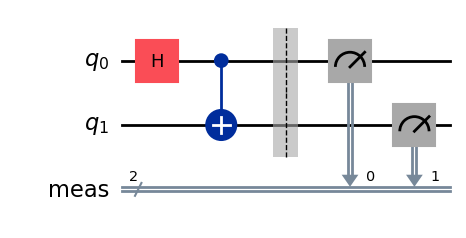

In [ ]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 2 qubits
bell = QuantumCircuit(2)

# Create the Bell state
bell.h(0)
bell.cx(0, 1)

# Measure both qubits
bell.measure_all()

# Display the circuit
bell.draw("mpl")

## Why Do We Need Many Shots?

A quantum circuit does not generally produce the same classical measurement result every time it is executed.

For the Bell state

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}},
\]

a single measurement produces either

\[
00
\]

or

\[
11.
\]

Each outcome has probability

\[
P(00)=P(11)=\frac{1}{2}.
\]

Therefore, we execute the circuit repeatedly.

Each repetition is called a **shot**.

For example, with 1000 shots we expect approximately

\[
00 \approx 500
\]

and

\[
11 \approx 500.
\]

The counts will usually not be exactly 500 and 500 because quantum measurement is probabilistic.

In [ ]:
from qiskit_aer import AerSimulator

# Create an ideal simulator
simulator = AerSimulator()

# Run the Bell-state circuit
job = simulator.run(bell, shots=1000)

# Obtain the result
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)

Measurement counts: {'00': 475, '11': 525}


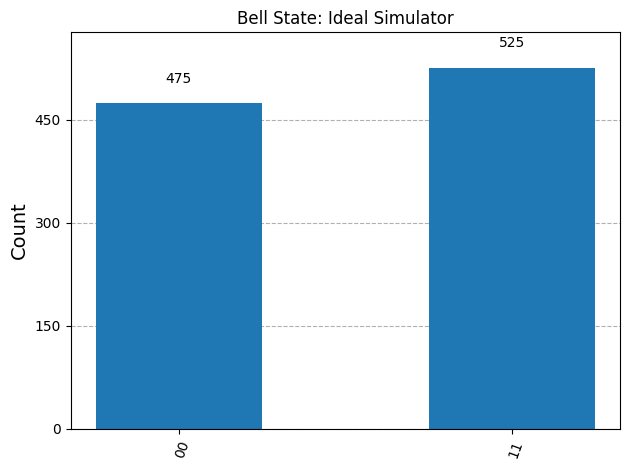

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(
    counts,
    title="Bell State: Ideal Simulator"
)

## Observation

The ideal simulator produces only two measurement outcomes:

- `00`
- `11`

Their frequencies are approximately equal.

The outcomes `01` and `10` should not occur in an ideal simulation.

This demonstrates an important property of the Bell state: although the result of each individual qubit is uncertain, the measurement outcomes of the two qubits are **correlated**.

If qubit 0 is measured as 0, qubit 1 is also measured as 0.

If qubit 0 is measured as 1, qubit 1 is also measured as 1.

This ideal result provides our **baseline**.

Later, we will execute the same logical computation on a real quantum processor and compare its output with this ideal result.

## Part 2: From a Logical Circuit to a Physical Quantum Computer

We have described our Bell-state computation using a simple circuit:

\[
H(0) \rightarrow CX(0,1) \rightarrow Measurement
\]

This is a **logical quantum circuit**.

It specifies **what computation we want to perform**, but it does not necessarily specify exactly **how a particular quantum processor will perform it**.

A real Quantum Processing Unit (QPU) has physical constraints.

### Some important hardware constraints

A real QPU has:

1. **A fixed number of physical qubits**

   Our logical qubits must be assigned to physical qubits on the processor.

2. **Limited qubit connectivity**

   A two-qubit operation cannot necessarily be performed directly between every pair of physical qubits.

3. **A hardware-supported instruction set**

   The gates used in our logical circuit may need to be expressed using instructions supported by the target processor.

4. **Imperfect operations**

   Physical gates, qubits, and measurements are affected by noise and other errors.

Therefore, before executing a logical circuit on a QPU, the circuit must be transformed so that it satisfies the constraints of the selected hardware.

This process is called **transpilation**.

## What is Transpilation?

In classical computing, a program written in a high-level language must eventually be translated into instructions that a processor can execute.

A similar idea appears in quantum computing.

We can think of the workflow as:

\[
\text{Logical Quantum Circuit}
\]

\[
\downarrow
\]

\[
\text{Transpiler}
\]

\[
\downarrow
\]

\[
\text{Hardware-Compatible Circuit}
\]

The transpiler considers properties of the target quantum processor such as:

- available physical qubits,
- qubit connectivity,
- supported instructions,
- and opportunities for circuit optimization.

Thus,

> **Transpilation transforms a logical quantum circuit into a circuit compatible with a particular target quantum processor.**

The logical computation should remain equivalent, but its physical implementation may look quite different.

## Before Transpiling: Know Your Target

Before executing our Bell-state circuit on real hardware, we need to know something about the target QPU.

We will investigate three basic questions:

### Question 1 — How many physical qubits are available?

A QPU contains a fixed number of physical qubits.

Our two logical qubits must eventually be mapped onto two of these physical qubits.

### Question 2 — Which qubits can interact?

Two-qubit operations depend on the connectivity supported by the processor.

This connectivity can be represented by a **coupling map** or other target connectivity information.

### Question 3 — Which instructions can the QPU execute?

The processor exposes a set of supported instructions.

Our logical circuit must be converted into operations compatible with this target instruction set.

These hardware properties make the target QPU an important input to the transpilation process.

## Logical Qubits and Physical Qubits

Consider our Bell-state circuit:

\[
q_0 \rightarrow H \rightarrow \bullet
\]

\[
q_1 \rightarrow \phantom{H} \rightarrow X
\]

Here, `q_0` and `q_1` are **logical qubits** in our program.

They do not initially refer to particular physical qubits inside an IBM quantum processor.

During transpilation, Qiskit determines how logical qubits should be represented using the physical qubits of the selected QPU.

For example, a transpilation could conceptually produce a mapping such as:

\[
q_0 \rightarrow \text{physical qubit 7}
\]

\[
q_1 \rightarrow \text{physical qubit 8}
\]

The actual mapping depends on the target processor and the transpilation process.

### Important distinction

**Logical qubit:**  
A qubit used to express the quantum algorithm or circuit.

**Physical qubit:**  
A physical device element on the quantum processor used to implement the computation.

## Think Before Proceeding

Suppose a quantum algorithm requires a two-qubit gate between two logical qubits.

After mapping, imagine that the corresponding physical qubits cannot directly support the required interaction.

### Question

Can the QPU simply execute the original two-qubit gate as written?

What might the transpiler have to do?

Do not worry about the exact solution yet.

In the next section, we will inspect a real IBM Quantum backend and see how Qiskit represents the capabilities and constraints of an actual QPU.

## Part 3: Connecting to IBM Quantum

So far, our Bell-state circuit has been executed using a local ideal simulator.

We will now connect our Colab notebook to **IBM Quantum Runtime**, which provides access to IBM quantum processors.

The workflow is:

\[
\text{Google Colab}
\rightarrow
\text{IBM Quantum Runtime}
\rightarrow
\text{Quantum Processing Unit (QPU)}
\]

To authenticate, an IBM Quantum account and an **API token** are required.

### Security Note

An API token is a private credential.

**Never:**

- include your token directly in a notebook that will be shared,
- upload a notebook containing your token to GitHub,
- send your token to another person.

In this lab, we will use the token only for authentication.

## Obtain Your IBM Quantum API Token

Before running the next cell:

1. Sign in to your IBM Quantum account.
2. Open your account/API-token settings.
3. Copy your API token.
4. Keep the token private.

We will use the token to create an authenticated connection through `QiskitRuntimeService`.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from getpass import getpass

# Enter the IBM Quantum API token securely
token = getpass("Enter your IBM Quantum API token: ")

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token
)

print("Successfully connected to IBM Quantum.")

Enter your IBM Quantum API token: ··········


qiskit_runtime_service._discover_account:WARNING:2026-09-14 06:20:43,820: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-14 06:20:47,068: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Successfully connected to IBM Quantum.


## Discover Available Quantum Processors

After authentication, IBM Quantum Runtime can provide information about the quantum processors available to our account.

A backend represents a computational system on which a quantum circuit can be executed.

For this experiment, we need a QPU that:

- is operational,
- is available to our account,
- has at least two qubits.

Rather than hard-coding the name of a particular processor, we will allow Qiskit Runtime to select an appropriate backend.

This makes the notebook less dependent on a particular IBM Quantum device remaining available.

In [ ]:
# Select an operational QPU with at least 2 qubits
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=2
)

print("Selected backend:", backend.name)
print("Number of qubits:", backend.num_qubits)

qiskit_runtime_service.backends:WARNING:2026-09-14 06:20:55,069: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-14 06:20:57,030: Using instance: open-instance, plan: open


Selected backend: ibm_kingston
Number of qubits: 156


## Inspect the Target QPU

We have now selected a real quantum processor.

Before transpiling our Bell-state circuit, let us inspect some characteristics of this processor.

We are particularly interested in:

1. the name of the processor,
2. the number of physical qubits,
3. the instructions supported by the processor.

These properties describe the **target** for which our logical circuit must be transpiled.

In [ ]:
print("Backend name:")
print(backend.name)

print("\nNumber of physical qubits:")
print(backend.num_qubits)

print("\nSupported operations:")
print(backend.operation_names)

Backend name:
ibm_kingston

Number of physical qubits:
156

Supported operations:
['if_else', 'measure_reset', 'xslow', 'cz', 'delay', 'sx', 'measure_reset_2', 'x', 'measure_2', 'rz', 'reset_2', 'measure', 'id', 'reset']


In [ ]:
target = backend.target

print(target)

Target
Number of qubits: 156
Instructions:
	if_else
	measure_reset
		(0,):
			Duration: 2.212e-06 sec.
		(1,):
			Duration: 2.212e-06 sec.
		(2,):
			Duration: 2.212e-06 sec.
		(3,):
			Duration: 2.212e-06 sec.
		(4,):
			Duration: 2.212e-06 sec.
		(5,):
			Duration: 2.212e-06 sec.
		(6,):
			Duration: 2.212e-06 sec.
		(7,):
			Duration: 2.212e-06 sec.
		(8,):
			Duration: 2.212e-06 sec.
		(9,):
			Duration: 2.212e-06 sec.
		(10,):
			Duration: 2.212e-06 sec.
		(11,):
			Duration: 2.212e-06 sec.
		(12,):
			Duration: 2.212e-06 sec.
		(13,):
			Duration: 2.212e-06 sec.
		(14,):
			Duration: 2.212e-06 sec.
		(15,):
			Duration: 2.212e-06 sec.
		(16,):
			Duration: 2.212e-06 sec.
		(17,):
			Duration: 2.212e-06 sec.
		(18,):
			Duration: 2.212e-06 sec.
		(19,):
			Duration: 2.212e-06 sec.
		(20,):
			Duration: 2.212e-06 sec.
		(21,):
			Duration: 2.212e-06 sec.
		(22,):
			Duration: 2.212e-06 sec.
		(23,):
			Duration: 2.212e-06 sec.
		(24,):
			Duration: 2.212e-06 sec.
		(25,):
			Durati

## Observation: A Circuit Needs a Target

Our Bell-state circuit was very simple:

\[
H(0) \rightarrow CX(0,1)
\]

However, the real QPU contains many physical qubits and exposes specific hardware instructions and connectivity constraints.

We therefore have two different descriptions:

### Logical description

Describes **what computation we want**.

\[
\text{Bell Circuit}
\]

### Hardware description

Describes **what the selected QPU can physically implement**.

\[
\text{QPU Target}
\]

The task of the transpiler is to reconcile these two descriptions:

\[
\boxed{\text{Logical Circuit}}
+
\boxed{\text{QPU Target}}
\longrightarrow
\boxed{\text{Hardware-Compatible Circuit}}
\]

This is why transpilation depends on the target quantum processor.

## Part 4: Transpiling the Bell Circuit for a Real QPU

Our selected quantum processor is:

**IBM Kingston — 156 physical qubits**

Our Bell-state circuit requires only two logical qubits:

\[
q_0,\;q_1
\]

The target processor, however, contains 156 physical qubits.

Therefore, Qiskit must determine how our two logical qubits will be implemented on the physical processor.

The transpilation process must consider:

- which physical qubits should be used,
- whether the required interactions are supported,
- how the logical gates should be expressed using instructions supported by the QPU,
- and how the resulting circuit can be optimized.

We will now transpile our Bell-state circuit specifically for `ibm_kingston`.

Original logical circuit
------------------------
Number of qubits: 2
Circuit depth: 3
Operations: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1})


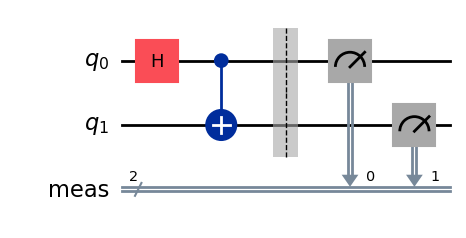

In [ ]:
print("Original logical circuit")
print("------------------------")

print("Number of qubits:", bell.num_qubits)
print("Circuit depth:", bell.depth())
print("Operations:", bell.count_ops())

bell.draw("mpl")

## Transpile the Circuit

Qiskit provides a **preset pass manager** for generating a circuit appropriate for a target backend.

We will use:

\[
\text{optimization\_level}=1
\]

At this level, Qiskit performs light optimization while transforming the circuit for the selected hardware.

Conceptually:

\[
\text{Bell Logical Circuit}
\]

\[
\downarrow
\]

\[
\text{Qiskit Transpiler}
+
\text{IBM Kingston Target}
\]

\[
\downarrow
\]

\[
\text{Hardware-Compatible Bell Circuit}
\]

The resulting circuit should implement the same computation, but its physical realization may differ from the circuit we originally wrote.

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Create a pass manager specifically for the selected QPU
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

# Transpile the Bell-state circuit
isa_bell = pm.run(bell)

print("Transpilation completed.")

Transpilation completed.


In [ ]:
print("ORIGINAL LOGICAL CIRCUIT")
print("------------------------")
print("Qubits:", bell.num_qubits)
print("Depth:", bell.depth())
print("Operations:", bell.count_ops())

print("\nTRANSPILED ISA CIRCUIT")
print("----------------------")
print("Qubits:", isa_bell.num_qubits)
print("Depth:", isa_bell.depth())
print("Operations:", isa_bell.count_ops())

ORIGINAL LOGICAL CIRCUIT
------------------------
Qubits: 2
Depth: 3
Operations: OrderedDict({'measure': 2, 'h': 1, 'cx': 1, 'barrier': 1})

TRANSPILED ISA CIRCUIT
----------------------
Qubits: 156
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})


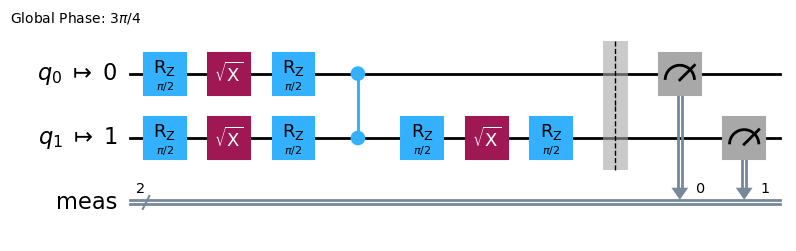

In [ ]:
isa_bell.draw(
    "mpl",
    idle_wires=False
)

## Observation: What Did Transpilation Change?

Compare the two circuits.

### Before transpilation

Our circuit expresses the computation in terms of logical qubits:

\[
q_0,\;q_1
\]

and familiar logical operations.

### After transpilation

The circuit has been transformed for the selected IBM QPU.

The transpiler may have changed:

- the mapping of logical qubits to physical qubits,
- the representation of quantum operations,
- the circuit depth,
- the number and type of operations.

However, the **intended computation remains equivalent**.

This illustrates an important principle:

> The quantum algorithm specifies the computation, while transpilation determines how that computation is implemented on a particular quantum processor.

In [ ]:
print(isa_bell.layout)

TranspileLayout(initial_layout=Layout({
0: <Qubit register=(2, "q"), index=0>,
1: <Qubit register=(2, "q"), index=1>,
2: <Qubit register=(154, "ancilla"), index=0>,
3: <Qubit register=(154, "ancilla"), index=1>,
4: <Qubit register=(154, "ancilla"), index=2>,
5: <Qubit register=(154, "ancilla"), index=3>,
6: <Qubit register=(154, "ancilla"), index=4>,
7: <Qubit register=(154, "ancilla"), index=5>,
8: <Qubit register=(154, "ancilla"), index=6>,
9: <Qubit register=(154, "ancilla"), index=7>,
10: <Qubit register=(154, "ancilla"), index=8>,
11: <Qubit register=(154, "ancilla"), index=9>,
12: <Qubit register=(154, "ancilla"), index=10>,
13: <Qubit register=(154, "ancilla"), index=11>,
14: <Qubit register=(154, "ancilla"), index=12>,
15: <Qubit register=(154, "ancilla"), index=13>,
16: <Qubit register=(154, "ancilla"), index=14>,
17: <Qubit register=(154, "ancilla"), index=15>,
18: <Qubit register=(154, "ancilla"), index=16>,
19: <Qubit register=(154, "ancilla"), index=17>,
20: <Qubit registe

## Think About the Mapping

Our quantum algorithm required only:

\[
2 \text{ logical qubits}
\]

but IBM Kingston contains:

\[
156 \text{ physical qubits}.
\]

The transpiler therefore had to determine where our logical qubits should be implemented on the physical processor.

### Questions

1. Which physical qubits were selected for our logical qubits?
2. Did the operations change after transpilation?
3. Did the circuit depth change?
4. Why might choosing different physical qubits affect execution quality?
5. Why should transpilation depend on the target QPU?

These questions illustrate that running a quantum algorithm involves more than simply constructing a quantum circuit.

## Interpreting the Transpilation Result

Our experiment produced the following transformation:

| Property | Logical Circuit | ISA Circuit |
|---|---:|---:|
| Qubits in circuit representation | 2 | 156 |
| Circuit depth | 3 | 8 |
| H gates | 1 | 0 |
| CX gates | 1 | 0 |
| RZ gates | 0 | 6 |
| SX gates | 0 | 3 |
| CZ gates | 0 | 1 |
| Measurements | 2 | 2 |

The original circuit contained

\[
H + CX
\]

whereas the transpiled circuit contains operations including

\[
RZ,\; SX,\; CZ.
\]

Why?

The original circuit describes the computation using convenient logical gates.

The target QPU exposes a particular set of hardware-supported instructions. The transpiler rewrites the logical operations into an equivalent sequence compatible with that target.

Thus,

\[
H + CX
\]

may become a sequence involving

\[
RZ + SX + CZ
\]

while preserving the intended computation.

The increase in circuit depth from

\[
3 \rightarrow 8
\]

shows that a simple logical circuit may require a more detailed hardware-compatible implementation.

In [ ]:
# Examine the layout produced by transpilation

layout = isa_bell.layout

print("Logical-to-physical mapping")
print("---------------------------")

for i in range(bell.num_qubits):
    physical = layout.initial_layout[bell.qubits[i]]
    print(f"Logical qubit q[{i}] -> Physical qubit {physical}")

Logical-to-physical mapping
---------------------------
Logical qubit q[0] -> Physical qubit 0
Logical qubit q[1] -> Physical qubit 1


## Interpreting the Qubit Mapping

The original Bell circuit contains two **logical qubits**:

\[
q_0,\;q_1
\]

During transpilation, these logical qubits are mapped onto physical qubits of the target QPU.

For our current transpilation, Qiskit selected:

\[
q_0 \rightarrow \text{physical qubit }0
\]

\[
q_1 \rightarrow \text{physical qubit }1
\]

The remaining physical-qubit positions appearing in the transpiled circuit representation are not additional qubits required by the Bell algorithm.

This distinction is important:

\[
\boxed{\text{2 logical qubits}}
\quad\longrightarrow\quad
\boxed{\text{2 selected physical qubits}}
\]

within a QPU containing

\[
\boxed{156\text{ physical qubits in total}}.
\]

The transpiler chooses a mapping that is compatible with the target processor and its supported interactions.

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Create a Sampler associated with the selected backend
sampler = Sampler(mode=backend)

# Submit the transpiled circuit to the real QPU
job = sampler.run([isa_bell], shots=1000)

print("Job ID:", job.job_id())
print("Job submitted to:", backend.name)

Job ID: dajpaqni3e6s738qj6gg
Job submitted to: ibm_kingston


In [ ]:
print("Job status:", job.status())

Job status: DONE


In [ ]:
result = job.result()

print("Hardware execution completed.")
print(result)

Hardware execution completed.
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-09-14 06:34:22', stop='2026-09-14 06:34:26', size=1000>)])}, 'version': 2})


In [ ]:
hardware_counts = result[0].data.meas.get_counts()

print("IBM Kingston measurement counts:")
print(hardware_counts)

IBM Kingston measurement counts:
{'11': 472, '10': 104, '01': 168, '00': 256}


## Results from the Real Quantum Processor

We executed the Bell-state circuit on **IBM Kingston** using 1000 shots.

The QPU produced:

| Outcome | Count | Observed Probability |
|---|---:|---:|
| `00` | 256 | 25.6% |
| `01` | 168 | 16.8% |
| `10` | 104 | 10.4% |
| `11` | 472 | 47.2% |

For an ideal Bell state, we expected only:

\[
00 \quad \text{and} \quad 11
\]

with approximately equal probabilities.

However, the real QPU also produced:

\[
01 \quad \text{and} \quad 10.
\]

This is our first direct experimental evidence that execution on real quantum hardware differs from ideal simulation.

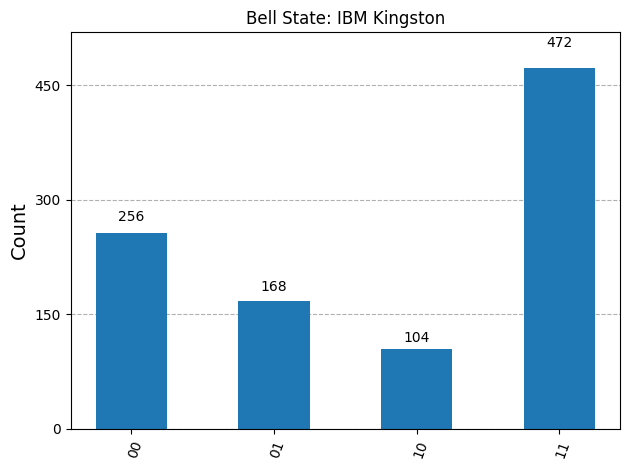

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(
    hardware_counts,
    title="Bell State: IBM Kingston"
)

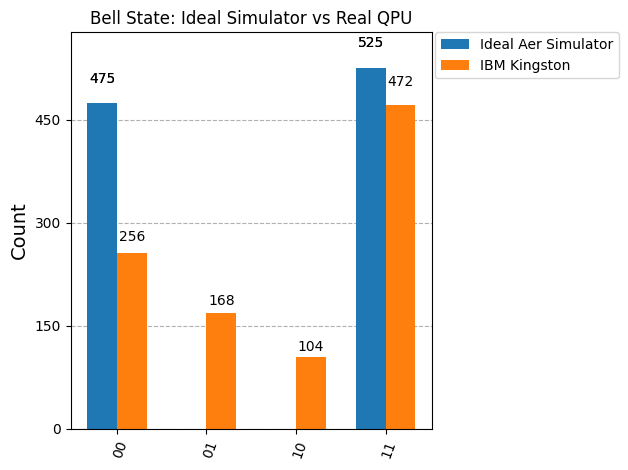

In [ ]:
plot_histogram(
    [counts, hardware_counts],
    legend=["Ideal Aer Simulator", "IBM Kingston"],
    title="Bell State: Ideal Simulator vs Real QPU"
)

## Quantifying the Difference

For the ideal Bell state,

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}},
\]

the expected outcomes are:

\[
P(00)=0.5,\qquad P(11)=0.5
\]

and

\[
P(01)=P(10)=0.
\]

We can therefore classify the measured outcomes into two groups.

### Expected Bell outcomes

\[
00,\;11
\]

### Unexpected outcomes

\[
01,\;10
\]

The fraction of unexpected outcomes provides a simple empirical measure of how much our hardware result differs from the ideal Bell-state prediction.

**Important:** This should not automatically be interpreted as the error rate of the QPU. It is an experiment-level observed deviation that can arise from several sources.

In [ ]:
total_shots = sum(hardware_counts.values())

expected_counts = (
    hardware_counts.get("00", 0)
    + hardware_counts.get("11", 0)
)

unexpected_counts = (
    hardware_counts.get("01", 0)
    + hardware_counts.get("10", 0)
)

expected_rate = expected_counts / total_shots
unexpected_rate = unexpected_counts / total_shots

print("Total shots:", total_shots)
print("Expected outcomes (00 + 11):", expected_counts)
print("Unexpected outcomes (01 + 10):", unexpected_counts)

print(f"\nExpected-outcome rate: {expected_rate:.2%}")
print(f"Unexpected-outcome rate: {unexpected_rate:.2%}")

Total shots: 1000
Expected outcomes (00 + 11): 728
Unexpected outcomes (01 + 10): 272

Expected-outcome rate: 72.80%
Unexpected-outcome rate: 27.20%


## Why Does Real Hardware Differ from the Ideal Simulator?

The ideal simulator assumes perfect quantum operations.

A real quantum processor is a physical system.

Several effects can cause the measured distribution to differ from the ideal prediction.

### 1. Gate imperfections

Quantum gates are implemented using physical control operations. They are not perfectly accurate.

### 2. Two-qubit gate imperfections

Entangling operations are particularly important because errors in these operations can affect the correlations required by the Bell state.

### 3. Measurement errors

The physical state of a qubit may be incorrectly classified during readout.

For example,

\[
0 \rightarrow 1
\]

or

\[
1 \rightarrow 0
\]

may occasionally be reported.

### 4. Decoherence

Qubits interact with their environment and gradually lose quantum information.

Two commonly discussed timescales are:

- \(T_1\): relaxation time
- \(T_2\): coherence/dephasing time

### 5. Circuit implementation

Our logical circuit had depth 3, while its hardware-compatible implementation had depth 8.

More physical operations and longer execution can create additional opportunities for imperfections to influence the final result.

Therefore, the appearance of `01` and `10` is not evidence that quantum theory failed.

Rather, it demonstrates the difference between an **ideal mathematical model** and its **physical implementation**.

## Student Activity: Analyse the Experimental Result

Using the results obtained from the real QPU, answer the following questions.

### Q1
What percentage of measurements produced the expected Bell-state outcomes?

### Q2
What percentage produced the unexpected outcomes `01` and `10`?

### Q3
Are `00` and `11` approximately equally distributed on the real QPU?

Compare:

\[
P(00)=25.6\%
\]

with

\[
P(11)=47.2\%.
\]

### Q4
Identify at least three physical effects that could contribute to the difference between the ideal and hardware results.

### Q5
Why should the 27.2% unexpected-outcome fraction **not** automatically be called the "error rate of IBM Kingston"?

### Q6
Which result should be regarded as the theoretical reference:

- the Aer ideal simulation, or
- the QPU experiment?

Explain your answer.

## Lab 3 Summary: From Quantum Circuit to Quantum Hardware

In this lab, we followed the complete journey of a quantum circuit from an abstract algorithm to execution on a real quantum processor.

### What We Did

We first constructed the Bell-state circuit

\[
|\Phi^+\rangle =
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
\]

and executed it using an ideal Aer simulator.

We then:

1. Connected Google Colab to IBM Quantum Runtime.
2. Selected the `ibm_kingston` quantum processor.
3. Examined the target QPU and its supported operations.
4. Transpiled our logical Bell circuit for the target hardware.
5. Observed that the logical gates

\[
H,\;CX
\]

were transformed into hardware-compatible operations involving

\[
RZ,\;SX,\;CZ.
\]

6. Observed that the circuit depth increased from

\[
3 \rightarrow 8.
\]

7. Executed the transpiled circuit on a real quantum processor.
8. Compared the hardware results with the ideal simulation.

### Our Experimental Result

From 1000 QPU shots, we obtained:

| Outcome | Count | Percentage |
|---|---:|---:|
| `00` | 256 | 25.6% |
| `01` | 168 | 16.8% |
| `10` | 104 | 10.4% |
| `11` | 472 | 47.2% |

The expected Bell outcomes accounted for

\[
P(00)+P(11)=72.8\%
\]

while the unexpected outcomes accounted for

\[
P(01)+P(10)=27.2\%.
\]

This experiment demonstrates an important distinction:

> **A quantum circuit is an abstract description of a computation. Transpilation converts that description into an implementation compatible with a particular quantum processor, and execution on real hardware is affected by physical imperfections.**

---

## Competency Check

After completing this lab, you should be able to explain:

- What is the difference between a logical and physical qubit?
- Why is transpilation required?
- What is an ISA circuit?
- Why can circuit depth increase after transpilation?
- Why can real QPU results differ from ideal simulator results?
- Why should unexpected measurement outcomes not automatically be interpreted as the QPU's error rate?

### Competency QC-C3

**I can transpile and execute a quantum circuit on real quantum hardware and interpret the effects of hardware constraints and noise.**

## Optional Challenge: Does Transpilation Optimization Matter?

So far, we used:

`optimization_level = 1`

Qiskit provides multiple transpilation optimization levels:

- Level 0 — minimal optimization
- Level 1 — light optimization
- Level 2 — more optimization
- Level 3 — heavier optimization

### Challenge

Transpile the same Bell-state circuit using optimization levels 0, 1, 2, and 3.

For each circuit, record:

| Optimization Level | Circuit Depth | Number of Operations | Physical Qubits Selected |
|---|---:|---:|---|
| 0 | | | |
| 1 | | | |
| 2 | | | |
| 3 | | | |

### Investigate

Does a higher optimization level always produce a shallower circuit?

Do all optimization levels select the same physical qubits?

What does this tell you about the role of the transpiler?

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

for level in range(4):

    pm_test = generate_preset_pass_manager(
        backend=backend,
        optimization_level=level
    )

    test_circuit = pm_test.run(bell)

    print(f"Optimization Level {level}")
    print("Depth:", test_circuit.depth())
    print("Operations:", test_circuit.count_ops())
    print("-" * 50)

Optimization Level 0
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 1
Depth: 8
Operations: OrderedDict({'rz': 6, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 2
Depth: 7
Operations: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
Optimization Level 3
Depth: 7
Operations: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})
--------------------------------------------------
